# Filtros de suavizado y reducción de ruido

**Duración estimada:** 80 minutos

## Objetivo

En este cuaderno vas a trabajar con una imagen real para estudiar cómo distintos filtros ayudan a limpiar ruido sin destruir por completo la información visual. Vamos a comparar tres estrategias clásicas: filtro gaussiano, filtro mediano y filtro bilateral.

## Resultados de aprendizaje

Al final de este cuaderno vas a poder:

- distinguir ruido gaussiano de ruido sal y pimienta;
- aplicar filtros de suavizado con OpenCV;
- explicar por qué el filtro mediano funciona tan bien con ruido impulsivo;
- comparar qué detalle preserva o destruye cada filtro;
- decidir qué filtro conviene probar primero en una imagen escaneada o estenopeica.

## Relación con cuadernos anteriores

Este cuaderno se apoya en lo que ya trabajaste en `001 - introduccion a opencv y espacios de color.ipynb` y en `004b - operaciones basicas con imagenes.ipynb`: leer una imagen, entender sus coordenadas y manipularla con OpenCV. Ahora damos un paso clave para restauración: **antes de reparar una foto, muchas veces necesitamos limpiarla**.


## 1. Concepto: qué significa “limpiar” una imagen

Cuando decimos que una imagen tiene ruido, no hablamos de “ruido” en sentido sonoro. Hablamos de variaciones espurias en los píxeles que no pertenecen a la escena original.

En restauración fotográfica esto importa mucho porque el ruido puede venir de varias fuentes:

- el escaneo de una copia en papel;
- el grano y la degradación química del material;
- polvo, suciedad o fallas de captura;
- sensores modestos o condiciones de iluminación muy pobres.

Cada filtro propone un compromiso distinto: reducir ruido sin borrar demasiado detalle. Ese “sin borrar demasiado” es la parte delicada.

[Pregunta para pensar]

Si un filtro logra que una imagen se vea más limpia, ¿eso significa automáticamente que recuperó información? ¿O puede ser que haya borrado señales importantes junto con el ruido?


In [1]:
from pathlib import Path
import urllib.request

import cv2
import numpy as np
import matplotlib.pyplot as plt


CARPETA_IMAGENES = Path("Imagenes")
CARPETA_IMAGENES.mkdir(exist_ok=True)

URL_IMAGEN = "https://raw.githubusercontent.com/opencv/opencv/4.x/samples/data/lena.jpg"
RUTA_IMAGEN = CARPETA_IMAGENES / "lena.jpg"


def descargar_imagen_si_falta(url, ruta_local):
    '''Descarga una imagen de referencia solo si todavía no existe en disco.'''
    if ruta_local.exists():
        print(f"La imagen ya estaba disponible en: {ruta_local}")
        return

    print("La imagen no estaba en la carpeta local. La descargamos ahora.")
    urllib.request.urlretrieve(url, ruta_local)
    print(f"Imagen descargada en: {ruta_local}")


def preparar_eje_imagen(eje, imagen, titulo, mapa=None):
    '''Muestra una imagen con ejes visibles para leer coordenadas.'''
    eje.imshow(imagen, cmap=mapa)
    eje.set_title(titulo, loc="left", fontweight="bold")
    eje.set_xlabel("x (columnas)")
    eje.set_ylabel("y (filas)")

    if imagen.ndim == 2:
        alto, ancho = imagen.shape
    else:
        alto, ancho = imagen.shape[:2]

    paso_x = max(50, ancho // 6)
    paso_y = max(50, alto // 6)
    eje.set_xticks(np.arange(0, ancho + 1, paso_x))
    eje.set_yticks(np.arange(0, alto + 1, paso_y))
    eje.grid(color="white", alpha=0.25, linewidth=0.6)


def mostrar_varias_imagenes(imagenes, titulos, mapas=None, tamano=(16, 5)):
    '''Muestra varias imágenes lado a lado manteniendo ejes visibles.'''
    if mapas is None:
        mapas = [None] * len(imagenes)

    figura, ejes = plt.subplots(1, len(imagenes), figsize=tamano, constrained_layout=True)
    if len(imagenes) == 1:
        ejes = [ejes]

    for eje, imagen, titulo, mapa in zip(ejes, imagenes, titulos, mapas):
        preparar_eje_imagen(eje, imagen, titulo, mapa)

    plt.show()


def recortar_region(imagen, x_inicio, y_inicio, ancho, alto):
    '''Devuelve un recorte rectangular para observar detalle fino.'''
    return imagen[y_inicio:y_inicio + alto, x_inicio:x_inicio + ancho]


def agregar_ruido_gaussiano(imagen_gris, media=0, desvio=18, semilla=24):
    '''Suma ruido gaussiano a una imagen en grises de manera reproducible.'''
    generador = np.random.default_rng(semilla)
    ruido = generador.normal(loc=media, scale=desvio, size=imagen_gris.shape)
    imagen_float = imagen_gris.astype(np.float32) + ruido
    imagen_ruidosa = np.clip(imagen_float, 0, 255).astype(np.uint8)
    return imagen_ruidosa


def agregar_ruido_sal_pimienta(imagen_gris, proporcion=0.06, semilla=24):
    '''Agrega ruido de sal y pimienta cambiando píxeles por 0 o 255.'''
    generador = np.random.default_rng(semilla)
    imagen_ruidosa = imagen_gris.copy()

    mascara_sal = generador.random(imagen_gris.shape) < (proporcion / 2)
    mascara_pimienta = generador.random(imagen_gris.shape) < (proporcion / 2)

    imagen_ruidosa[mascara_sal] = 255
    imagen_ruidosa[mascara_pimienta] = 0
    return imagen_ruidosa


def calcular_error_medio_absoluto(imagen_referencia, imagen_prueba):
    '''Calcula una medida simple de distancia entre dos imágenes.'''
    diferencia = np.abs(imagen_referencia.astype(np.float32) - imagen_prueba.astype(np.float32))
    return diferencia.mean()


descargar_imagen_si_falta(URL_IMAGEN, RUTA_IMAGEN)


La imagen ya estaba disponible en: Imagenes\lena.jpg


## 2. Ejercicio guiado: partir de una imagen real y construir degradaciones controladas

En vez de inventar una imagen desde cero, vamos a trabajar con una fotografía real de referencia. Después le vamos a agregar ruido de forma programática. Eso nos da una ventaja didáctica fuerte: conocemos la imagen base y, por lo tanto, podemos comparar mejor qué destruye y qué conserva cada filtro.

Primero vamos a abrir la imagen y a pasarla a escala de grises. Elegimos grises porque así el efecto del ruido y de los filtros se vuelve más fácil de leer.


Forma de la imagen original: (512, 512, 3)
Forma de la imagen en grises: (512, 512)


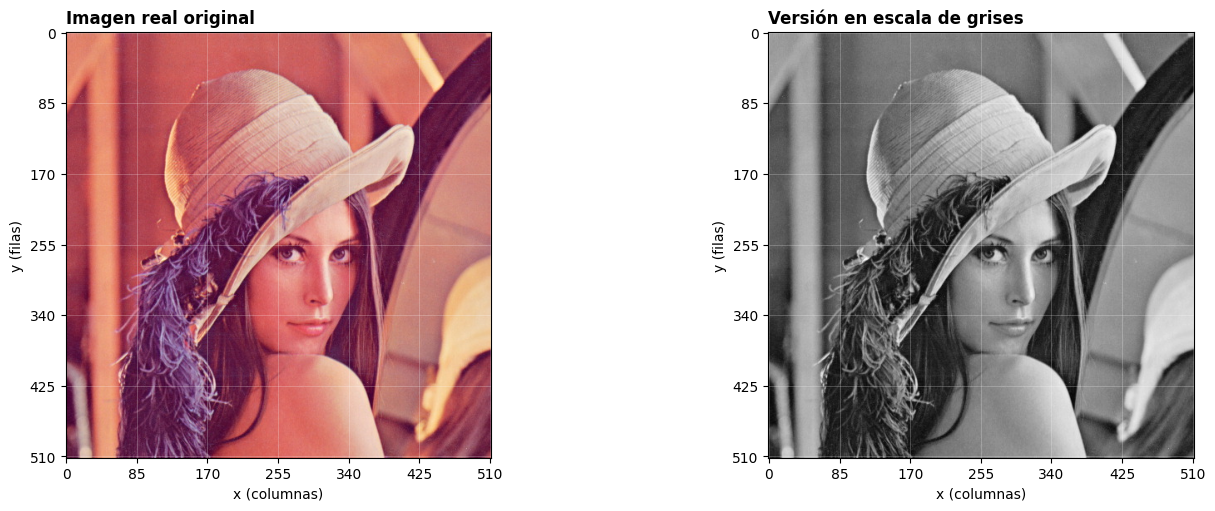

In [2]:
imagen_bgr = cv2.imread(str(RUTA_IMAGEN), cv2.IMREAD_COLOR)
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
imagen_gris = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2GRAY)

print("Forma de la imagen original:", imagen_rgb.shape)
print("Forma de la imagen en grises:", imagen_gris.shape)

mostrar_varias_imagenes(
    [imagen_rgb, imagen_gris],
    ["Imagen real original", "Versión en escala de grises"],
    [None, "gray"],
    tamano=(14, 5),
)


**Qué observar**

- La imagen en grises simplifica la escena a un solo canal de intensidad.
- Los bordes principales siguen ahí: sombrero, cara, pelo, fondo.

**Qué conclusión podés sacar**

- Para estudiar ruido y suavizado, muchas veces conviene reducir complejidad y trabajar en un solo canal.

**Qué limitación tiene este paso**

- Si el color fuera importante para decidir qué es ruido y qué es señal, esta simplificación podría ocultar información relevante.


Ahora vamos a generar dos versiones degradadas:

- una con **ruido gaussiano**, que simula pequeñas variaciones distribuidas por toda la imagen;
- otra con **ruido sal y pimienta**, que introduce puntos negros y blancos muy agresivos.

Además, vamos a marcar una región de interés para mirar con más detalle qué pasa en un sector con bordes y texturas finas.


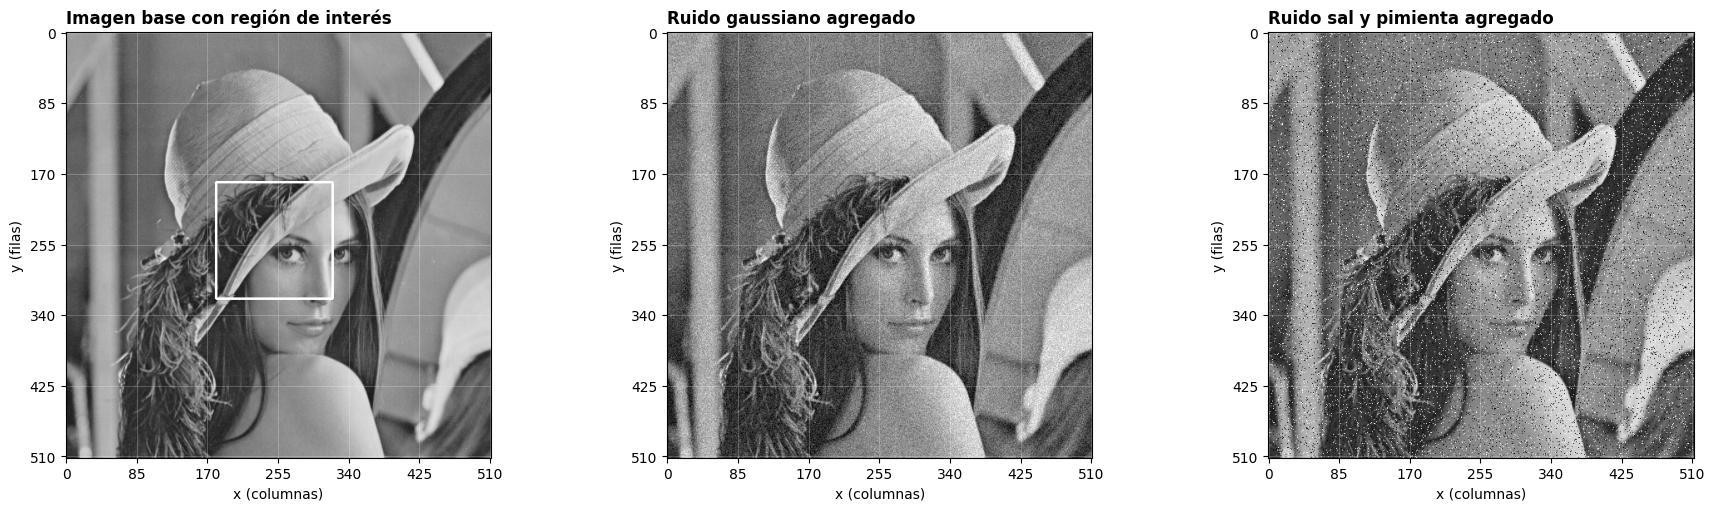

In [3]:
imagen_con_ruido_gaussiano = agregar_ruido_gaussiano(imagen_gris, media=0, desvio=18, semilla=24)
imagen_con_ruido_sal_pimienta = agregar_ruido_sal_pimienta(imagen_gris, proporcion=0.08, semilla=24)

x_region = 180
y_region = 180
ancho_region = 140
alto_region = 140

imagen_con_region = cv2.cvtColor(imagen_gris, cv2.COLOR_GRAY2RGB)
cv2.rectangle(
    imagen_con_region,
    (x_region, y_region),
    (x_region + ancho_region, y_region + alto_region),
    (255, 255, 255),
    2,
)

mostrar_varias_imagenes(
    [imagen_con_region, imagen_con_ruido_gaussiano, imagen_con_ruido_sal_pimienta],
    [
        "Imagen base con región de interés",
        "Ruido gaussiano agregado",
        "Ruido sal y pimienta agregado",
    ],
    [None, "gray", "gray"],
    tamano=(18, 5),
)


**Qué observar**

- El ruido gaussiano ensucia casi toda la imagen con una textura granulada fina.
- El ruido sal y pimienta introduce píxeles extremos, muy oscuros o muy claros.

**Qué conclusión podés sacar**

- Aunque ambos casos “molestan”, no degradan la imagen del mismo modo. Por eso no conviene asumir que un solo filtro sirve para cualquier situación.

**Qué limitación tiene este experimento**

- En una foto real el ruido no siempre aparece tan “puro”. Muchas veces se mezclan varios tipos de degradación a la vez.


## 3. Automatización con Python: aplicar filtros y compararlos

Ahora vamos a probar tres filtros clásicos.

- **Gaussiano:** suaviza en general, pero puede borrar bordes finos.
- **Mediano:** reemplaza cada píxel por la mediana de su vecindad; suele funcionar muy bien con sal y pimienta.
- **Bilateral:** suaviza, pero intenta preservar bordes fuertes.

Fijate que no estamos buscando “el filtro ganador universal”. Queremos entender **qué resuelve cada uno y qué precio paga**.


In [4]:
# Filtros sobre la imagen con ruido gaussiano.
gaussiano_sobre_gaussiano = cv2.GaussianBlur(imagen_con_ruido_gaussiano, (5, 5), 0)
mediano_sobre_gaussiano = cv2.medianBlur(imagen_con_ruido_gaussiano, 5)
bilateral_sobre_gaussiano = cv2.bilateralFilter(imagen_con_ruido_gaussiano, 9, 40, 40)

# Filtros sobre la imagen con ruido sal y pimienta.
gaussiano_sobre_sal_pimienta = cv2.GaussianBlur(imagen_con_ruido_sal_pimienta, (5, 5), 0)
mediano_sobre_sal_pimienta = cv2.medianBlur(imagen_con_ruido_sal_pimienta, 5)
bilateral_sobre_sal_pimienta = cv2.bilateralFilter(imagen_con_ruido_sal_pimienta, 9, 40, 40)


Primero vamos a mirar el caso del **ruido gaussiano**.


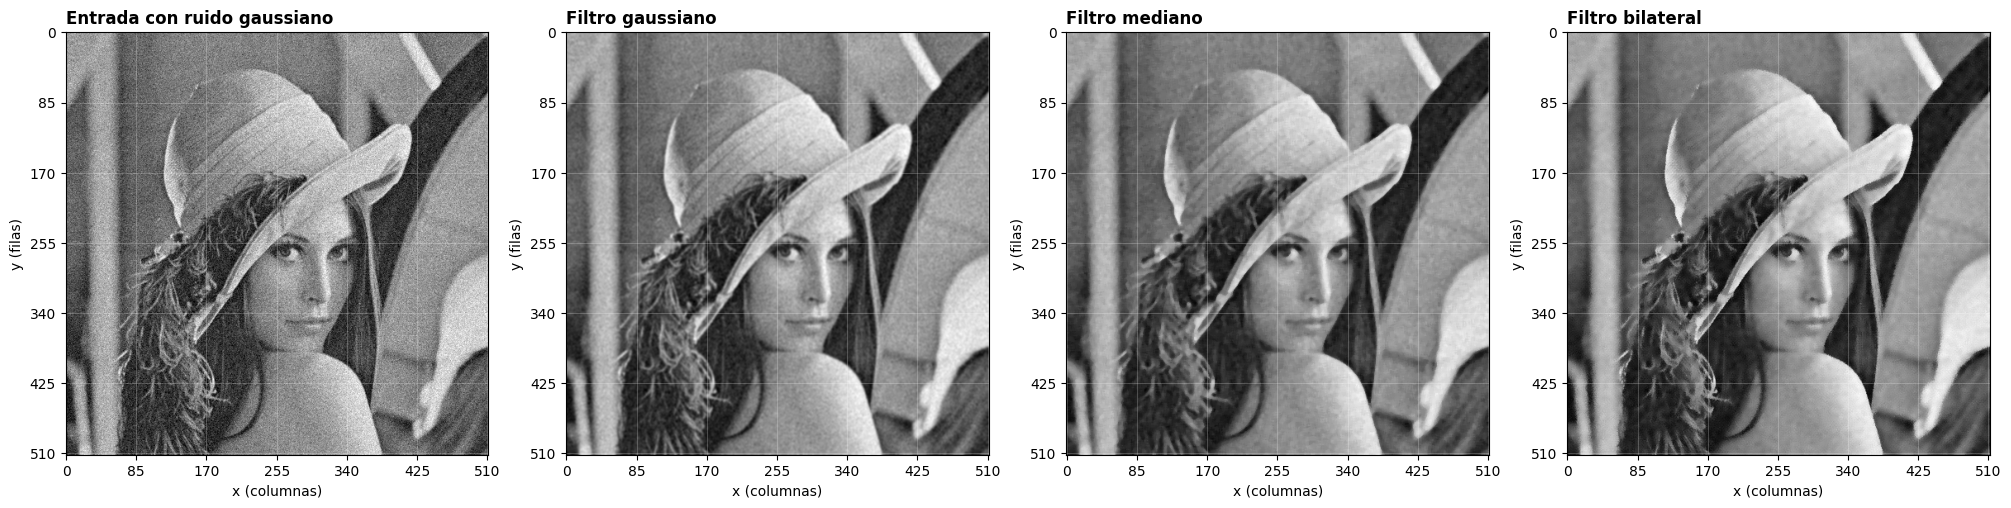

In [5]:
mostrar_varias_imagenes(
    [
        imagen_con_ruido_gaussiano,
        gaussiano_sobre_gaussiano,
        mediano_sobre_gaussiano,
        bilateral_sobre_gaussiano,
    ],
    [
        "Entrada con ruido gaussiano",
        "Filtro gaussiano",
        "Filtro mediano",
        "Filtro bilateral",
    ],
    ["gray", "gray", "gray", "gray"],
    tamano=(20, 5),
)


**Qué observar**

- El filtro gaussiano limpia bastante bien el grano fino, pero suaviza también las transiciones.
- El bilateral suele preservar mejor algunos bordes duros.
- El mediano funciona, pero no necesariamente es la mejor primera opción en este caso.

**Qué conclusión podés sacar**

- Frente a un ruido distribuido de manera más homogénea, gaussiano y bilateral suelen tener más sentido que el mediano.

**Qué limitación tiene esta lectura**

- Mirar la imagen completa a veces oculta pérdidas sutiles de detalle. Por eso ahora vamos a acercarnos a una región concreta.


Ahora vamos a mirar el caso del **ruido sal y pimienta**, que es el más importante para este cuaderno.


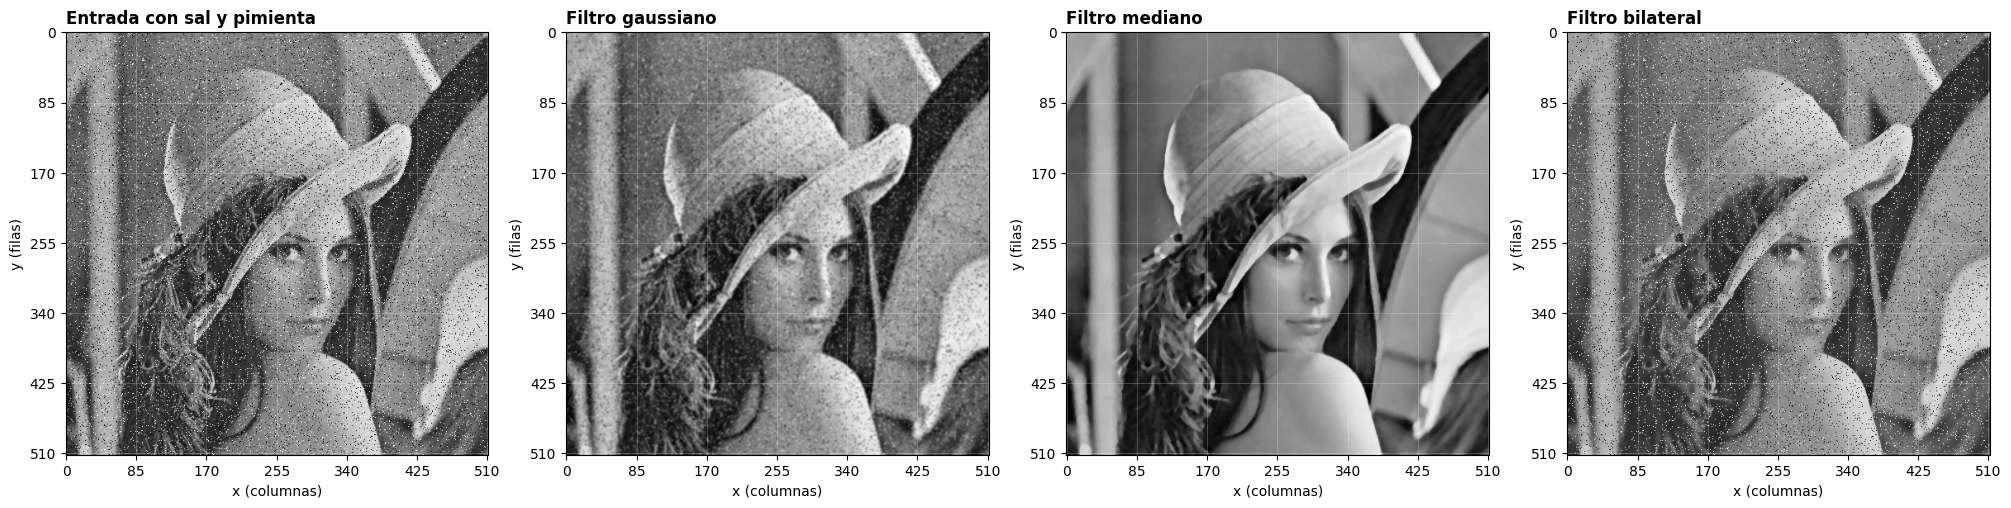

In [6]:
mostrar_varias_imagenes(
    [
        imagen_con_ruido_sal_pimienta,
        gaussiano_sobre_sal_pimienta,
        mediano_sobre_sal_pimienta,
        bilateral_sobre_sal_pimienta,
    ],
    [
        "Entrada con sal y pimienta",
        "Filtro gaussiano",
        "Filtro mediano",
        "Filtro bilateral",
    ],
    ["gray", "gray", "gray", "gray"],
    tamano=(20, 5),
)


**Qué observar**

- El filtro mediano elimina gran parte de los puntos negros y blancos aislados.
- El gaussiano tiende a “desparramar” esos impulsos y deja una imagen más lavada.
- El bilateral ayuda, pero no limpia tan bien los impulsos extremos como el mediano.

**Qué conclusión se puede sacar**

- El ruido sal y pimienta no se reduce solo “promediando”. Necesita una estrategia robusta a valores extremos, y ahí la mediana tiene una ventaja clara.

**Qué limitación tiene lo que acabamos de ver**

- Si aumentáramos mucho el tamaño del kernel del filtro mediano, también empezaríamos a perder detalle útil.


## 4. Reflexión guiada

[Pregunta para pensar]

El filtro mediano parece “hacer magia” con el ruido sal y pimienta. Pero, si mirás el procedimiento bajo el capó, no está recuperando el valor original del píxel perdido: está decidiendo un valor plausible a partir del vecindario.

- ¿Hasta qué punto eso sigue siendo “limpieza” y no ya una forma de reescritura local de la imagen?
- ¿Qué pasaría si el detalle importante fuera un punto muy pequeño, del tamaño del ruido que queremos borrar?
- ¿Cómo cambia nuestra decisión si estamos restaurando una foto para archivo y no solo para verla “más linda”?


## 5. Ejemplo práctico: comparar una región de detalle fino

Vamos a mirar la misma zona recortada en la imagen original, en la imagen degradada y en las imágenes filtradas. Esta comparación local suele ser mucho más útil que una impresión global rápida.


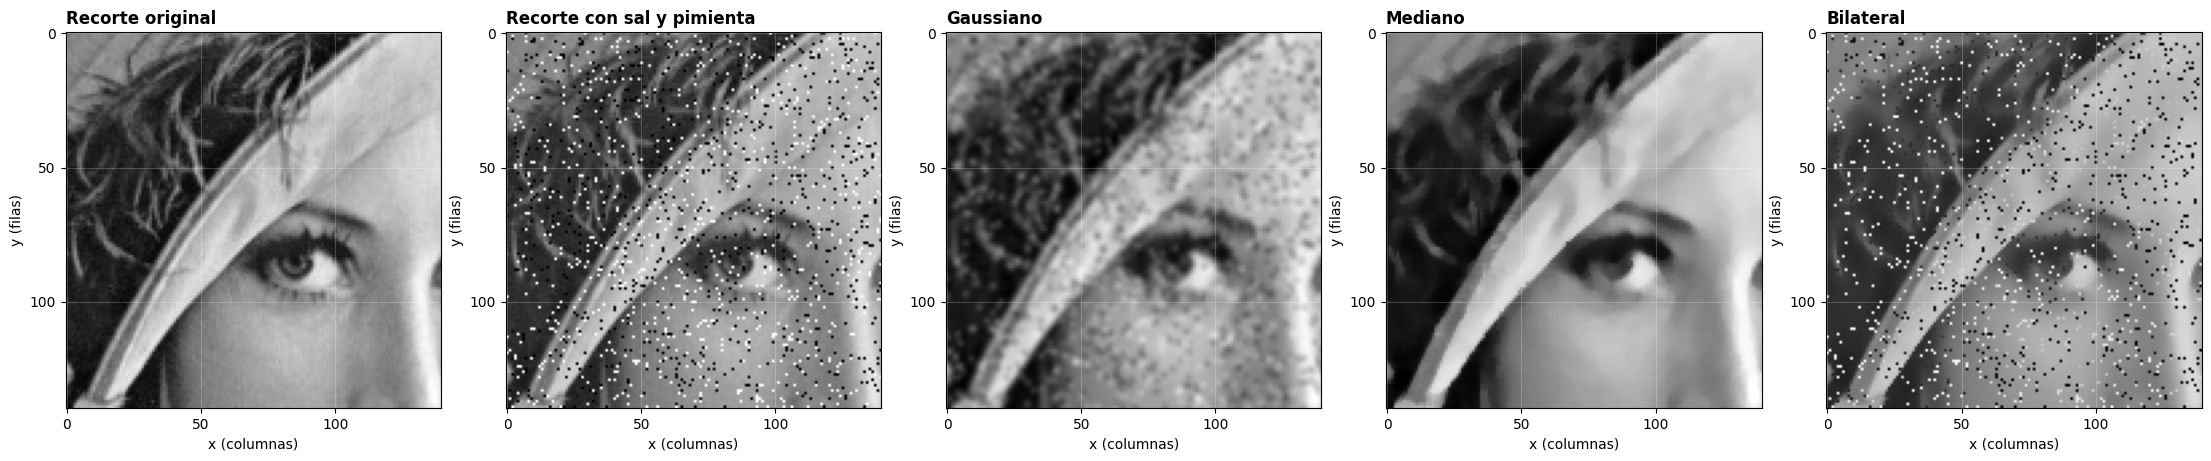

Error medio absoluto - filtro gaussiano: 8.90
Error medio absoluto - filtro mediano: 3.95
Error medio absoluto - filtro bilateral: 11.93


In [7]:
recorte_original = recortar_region(imagen_gris, x_region, y_region, ancho_region, alto_region)
recorte_ruido_sp = recortar_region(imagen_con_ruido_sal_pimienta, x_region, y_region, ancho_region, alto_region)
recorte_gaussiano = recortar_region(gaussiano_sobre_sal_pimienta, x_region, y_region, ancho_region, alto_region)
recorte_mediano = recortar_region(mediano_sobre_sal_pimienta, x_region, y_region, ancho_region, alto_region)
recorte_bilateral = recortar_region(bilateral_sobre_sal_pimienta, x_region, y_region, ancho_region, alto_region)

mostrar_varias_imagenes(
    [
        recorte_original,
        recorte_ruido_sp,
        recorte_gaussiano,
        recorte_mediano,
        recorte_bilateral,
    ],
    [
        "Recorte original",
        "Recorte con sal y pimienta",
        "Gaussiano",
        "Mediano",
        "Bilateral",
    ],
    ["gray", "gray", "gray", "gray", "gray"],
    tamano=(22, 5),
)

error_gaussiano = calcular_error_medio_absoluto(imagen_gris, gaussiano_sobre_sal_pimienta)
error_mediano = calcular_error_medio_absoluto(imagen_gris, mediano_sobre_sal_pimienta)
error_bilateral = calcular_error_medio_absoluto(imagen_gris, bilateral_sobre_sal_pimienta)

print(f"Error medio absoluto - filtro gaussiano: {error_gaussiano:.2f}")
print(f"Error medio absoluto - filtro mediano: {error_mediano:.2f}")
print(f"Error medio absoluto - filtro bilateral: {error_bilateral:.2f}")


**Qué observar**

- En el recorte se ve mucho mejor qué bordes se conservan y cuáles se degradan.
- El error medio absoluto no reemplaza la lectura visual, pero ayuda a sostener la comparación con una medida simple.

**Qué conclusión se puede sacar**

- Para este tipo de degradación, el filtro mediano suele dar el mejor equilibrio entre limpieza y conservación de la forma local.

**Qué limitación tiene este ejemplo**

- Una sola métrica no alcanza para decidir la mejor restauración. En patrimonio visual también importan la textura, la legibilidad y la fidelidad histórica del material.


## 6. Limitaciones y próximos pasos

Ningún filtro de suavizado resuelve por sí solo todos los problemas de una imagen degradada.

- El gaussiano suaviza bien, pero borra bordes.
- El mediano es excelente para ruido impulsivo, pero puede deformar estructuras pequeñas si exageramos el kernel.
- El bilateral preserva bordes, pero puede ser más costoso y no siempre vence al mediano en sal y pimienta.

En una restauración real, muchas veces primero limpiamos ruido y después pasamos a detectar daño, construir máscaras y recién ahí reparar zonas faltantes.

## Actividad breve

Probá cambiar estos parámetros y registrá qué pasó:

1. el tamaño del kernel del filtro mediano;
2. la proporción de ruido sal y pimienta;
3. la intensidad del ruido gaussiano.

Después escribí una conclusión breve: **¿qué filtro probarías primero sobre una foto escaneada con polvo o puntitos blancos y negros?**

## Cierre

En este cuaderno estudiaste cómo limpiar ruido sobre una imagen real usando degradaciones controladas. En el próximo paso vamos a pasar de limpiar píxeles a limpiar **máscaras binarias**, que es una pieza clave para localizar daños antes de restaurarlos.
